# Machine Learning - Second Hand Car Price Prediction
---

## Import data and libraries

In [1]:
# base modules
from pathlib import Path
import logging
from collections import OrderedDict

# for manipulating data
import numpy as np
import pandas as pd
import math
from typing import Callable
import copy
import re
from pandas.api.types import is_string_dtype, is_numeric_dtype


# for Machine Learning
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV,train_test_split

# for visualization
from matplotlib import pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# for package auto reload
%load_ext autoreload
%autoreload 2

# for better rendering of plots in jupyter notebook
%matplotlib inline

In [2]:
import optuna

In [3]:
import sys
import os
sys.path.append(os.path.abspath("../feature"))
from feature_engineering import outliers_proc, feature_engineering
from transform_to_log import transform_price_to_log
from process_data import fix_missing, process_df, numericalize, reduce_mem_usage


In [4]:
df=pd.read_csv('../data/used_car_train_20200313.csv', sep=' ')

---
## Data Processing & Feature Engineering

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SaleID,150000.0,NaN,NaN,NaN,74999.5,43301.414527,0.0,37499.75,74999.5,112499.25,149999.0
name,150000.0,NaN,NaN,NaN,68349.172873,61103.875095,0.0,11156.0,51638.0,118841.25,196812.0
regDate,150000.0,NaN,NaN,NaN,20034170.51218,53649.879255,19910001.0,19990912.0,20030912.0,20071109.0,20151212.0
model,149999.0,NaN,NaN,NaN,47.129021,49.53604,0.0,10.0,30.0,66.0,247.0
brand,150000.0,NaN,NaN,NaN,8.052733,7.864956,0.0,1.0,6.0,13.0,39.0
bodyType,145494.0,NaN,NaN,NaN,1.792369,1.76064,0.0,0.0,1.0,3.0,7.0
fuelType,141320.0,NaN,NaN,NaN,0.375842,0.548677,0.0,0.0,0.0,1.0,6.0
gearbox,144019.0,NaN,NaN,NaN,0.224943,0.417546,0.0,0.0,0.0,0.0,1.0
power,150000.0,NaN,NaN,NaN,119.316547,177.168419,0.0,75.0,110.0,150.0,19312.0
kilometer,150000.0,NaN,NaN,NaN,12.59716,3.919576,0.5,12.5,15.0,15.0,15.0


In [6]:
df["seller"].value_counts()

seller
0    149999
1         1
Name: count, dtype: int64

In [7]:
df["offerType"].value_counts()

offerType
0    150000
Name: count, dtype: int64

In [8]:
del df["seller"]
del df["offerType"]

In [9]:
y = df['price']
sns.histplot(y, kde=True)
plt.title('Normal')

Text(0.5, 1.0, 'Normal')

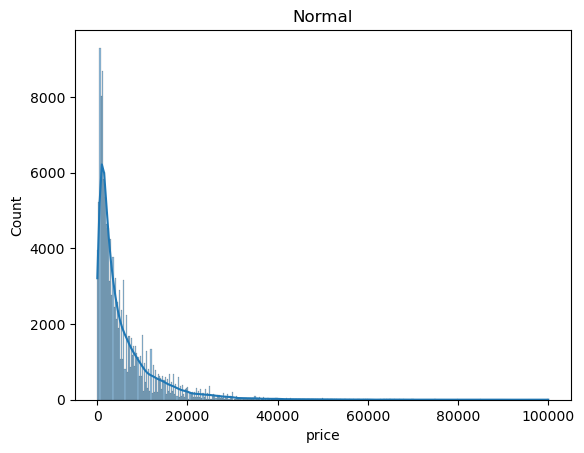

In [10]:
plt.show()

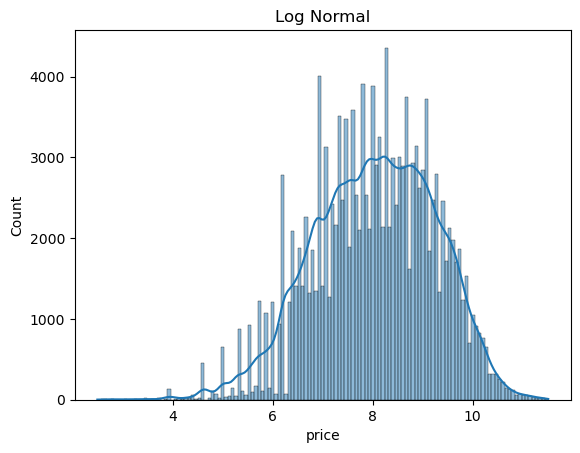

In [11]:
sns.histplot(np.log1p(y), kde=True) 
plt.title('Log Normal')
plt.show()

Saved to ../user_data/price_log_transform.csv
Delete number is: 127
Now row count is: 149873
Description of data less than the lower bound is:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: power, dtype: float64
Description of data larger than the upper bound is:
count      127.000000
mean      3498.811024
std       4498.219286
min        650.000000
25%       1037.500000
50%       1503.000000
75%       2760.500000
max      19312.000000
Name: power, dtype: float64


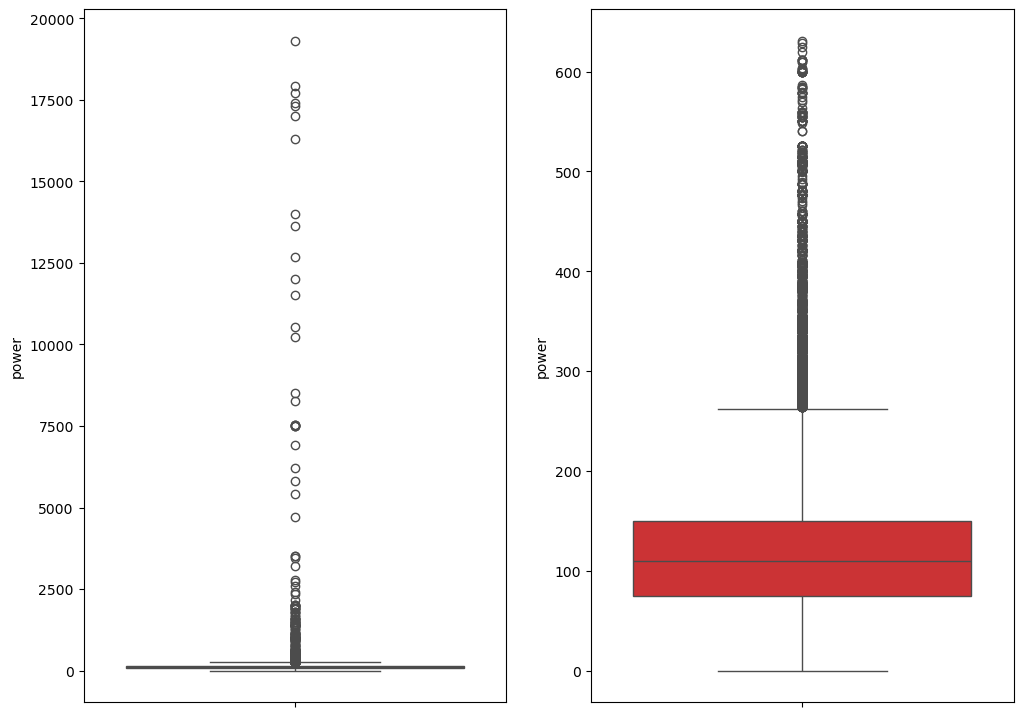

In [12]:
df_log=transform_price_to_log(df, save_path='../user_data/price_log_transform.csv')
df_log=outliers_proc(df_log, 'power',scale=3)
df_fe=feature_engineering(df_log)

In [13]:
df_fe=reduce_mem_usage(df_fe)

Memory usage of dataframe is 37168636.00 MB
Memory usage after optimization is: 10491242.00 MB
Decreased by 71.8%


In [14]:
df_pr,y=process_df(df_fe,'price_log')
print(df_pr.shape)

(149873, 39)


In [15]:
df_pr.head()

,SaleID,name,model,brand,bodyType,fuelType,gearbox,power,kilometer,notRepairedDamage,...,power_bin,model_na,bodyType_na,fuelType_na,gearbox_na,notRepairedDamage_na,used_time_na,km_per_year_na,power_age_na,power_bin_na
0,0,736,30.0,6,1.0,0.0,0.0,60,12.5,0.0,...,5.0,0,0,0,0,0,0,0,0,0
1,1,2262,40.0,1,2.0,0.0,0.0,0,15.0,0.0,...,11.0,0,0,0,0,1,0,0,0,1
2,2,14874,115.0,15,1.0,0.0,0.0,163,12.5,0.0,...,16.0,0,0,0,0,0,0,0,0,0
3,3,71865,109.0,10,0.0,0.0,1.0,193,15.0,0.0,...,19.0,0,0,0,0,0,0,0,0,0
4,4,111080,110.0,5,1.0,0.0,0.0,68,5.0,0.0,...,6.0,0,0,0,0,0,0,0,0,0


In [16]:
len(y)
y

array([7.52348131, 8.18896686, 8.73600738, ..., 8.92279162, 8.51719319,
       8.45553053], shape=(149873,))

In [17]:
df_pr.columns

Index(['SaleID', 'name', 'model', 'brand', 'bodyType', 'fuelType', 'gearbox',
       'power', 'kilometer', 'notRepairedDamage', 'v_0', 'v_1', 'v_2', 'v_3',
       'v_4', 'v_5', 'v_6', 'v_7', 'v_8', 'v_9', 'v_10', 'v_11', 'v_12',
       'v_13', 'v_14', 'used_time', 'city', 'km_per_year', 'power_age',
       'power_bin', 'model_na', 'bodyType_na', 'fuelType_na', 'gearbox_na',
       'notRepairedDamage_na', 'used_time_na', 'km_per_year_na',
       'power_age_na', 'power_bin_na'],
      dtype='object')

---

## Base model

---
## Split Train & Validation set

In [18]:
N_valid = 30000
N_small = 30000
X_train, X_valid, y_train, y_valid = train_test_split(df_pr, y, test_size=N_valid, random_state=42)
_, X_small, _, y_small = train_test_split(X_train, y_train, test_size=N_small, random_state=42)
print("Large training set size : ",X_train.shape, y_train.shape)
print("Small training set size : ",X_small.shape, y_small.shape)
print("Validation set size : ",X_valid.shape, y_valid.shape)

Large training set size :  (119873, 39) (119873,)
Small training set size :  (30000, 39) (30000,)
Validation set size :  (30000, 39) (30000,)


In [19]:
X_train.columns

Index(['SaleID', 'name', 'model', 'brand', 'bodyType', 'fuelType', 'gearbox',
       'power', 'kilometer', 'notRepairedDamage', 'v_0', 'v_1', 'v_2', 'v_3',
       'v_4', 'v_5', 'v_6', 'v_7', 'v_8', 'v_9', 'v_10', 'v_11', 'v_12',
       'v_13', 'v_14', 'used_time', 'city', 'km_per_year', 'power_age',
       'power_bin', 'model_na', 'bodyType_na', 'fuelType_na', 'gearbox_na',
       'notRepairedDamage_na', 'used_time_na', 'km_per_year_na',
       'power_age_na', 'power_bin_na'],
      dtype='object')

- define root mean squared error

In [20]:
def rmse(y_gold, y_pred): 
    return math.sqrt(((y_gold - y_pred)**2).mean())

- define print score(train/valid+oob)

In [21]:
def print_score(m, X_train, y_train, X_valid, y_valid, log_target=True):
    y_train_pred_log = m.predict(X_train)
    y_valid_pred_log = m.predict(X_valid)
    print('1. RMSE on train set (log_price): {:.4f}'.format(rmse(y_train, y_train_pred_log)))
    print('2. RMSE on valid set (log_price): {:.4f}'.format(rmse(y_valid, y_valid_pred_log)))
    print('3. MAE on train set (log_price): {:.4f}'.format(mean_absolute_error(y_train, y_train_pred_log)))
    print('4. MAE on valid set (log_price): {:.4f}'.format(mean_absolute_error(y_valid, y_valid_pred_log)))
    if log_target:
        y_train_real      = np.expm1(y_train)
        y_valid_real      = np.expm1(y_valid)
        y_train_pred_real = np.expm1(y_train_pred_log)
        y_valid_pred_real = np.expm1(y_valid_pred_log)
        print('5. R^2 on train set (original price): {:.4f}'.format(
            r2_score(y_train_real, y_train_pred_real)))
        print('6. R^2 on valid set (original price): {:.4f}'.format(
            r2_score(y_valid_real, y_valid_pred_real)))

    else:
        print('5. R^2 on train set: {:.4f}'.format(m.score(X_train, y_train)))
        print('6. R^2 on valid set: {:.4f}'.format(m.score(X_valid, y_valid)))
    if hasattr(m, 'oob_score_'):
        print('R^2 on oob set: {:.4f}'.format(m.oob_score_))

    return

---
## Random Forest

---
## Random Forest Hyperparmeter tuning

- Best model gird search

In [23]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [20, 30, None],
    'min_samples_split': [2, 4],
    'max_features': ['sqrt', 0.5],
    'max_samples': [0.8, None], 
}
model = RandomForestRegressor(
    random_state = 42,
    bootstrap = True,
    n_jobs=-1
)

In [24]:
tuned_model = GridSearchCV(
    estimator = model, 
    param_grid = param_grid, 
    scoring = None, 
    n_jobs = -1, 
    refit = True, 
    cv = 5, 
    return_train_score = True,
    verbose = 2,
)

In [25]:
tuned_model.fit(X_small, y_small)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [20, 30, ...], 'max_features': ['sqrt', 0.5], 'max_samples': [0.8, None], 'min_samples_split': [2, 4], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,200


In [26]:
rf_hybest = tuned_model.best_estimator_
rf_hybest

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
print_score(rf_hybest, X_small, y_small, X_valid, y_valid)

1. RMSE on train set (log_price): 0.0964
2. RMSE on valid set (log_price): 0.2525
3. MAE on train set (log_price): 0.0561
4. MAE on valid set (log_price): 0.1494
5. R^2 on train set (original price): 0.9893
6. R^2 on valid set (original price): 0.9546


In [28]:
%time rf_hybest.fit(X_train, y_train)
print_score(rf_hybest, X_train, y_train, X_valid, y_valid)

CPU times: total: 5min 12s
Wall time: 24.9 s
1. RMSE on train set (log_price): 0.0891
2. RMSE on valid set (log_price): 0.2344
3. MAE on train set (log_price): 0.0496
4. MAE on valid set (log_price): 0.1323
5. R^2 on train set (original price): 0.9931
6. R^2 on valid set (original price): 0.9668


---
## Random Forest Hyperparmeter tuning using Optuna

In [29]:
def objective(trial, X_training, y_training, X_validation, y_validation):
    n_estimators = trial.suggest_int('n_estimators', 100, 2500) 
    max_depth = trial.suggest_int('max_depth', 5, 60, log=True) 
    min_samples_split = trial.suggest_int('min_samples_split', 2, 50, log=True) 
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 30, log=True) 
    max_features = trial.suggest_float('max_features', 0.1, 1.0)
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    max_samples = trial.suggest_float('max_samples', 0.5, 1.0, step=0.05) if bootstrap else None
    
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        max_samples=max_samples, 
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_training, y_training)

    y_pred_validation = rf.predict(X_validation)
    r2_validation = metrics.r2_score(y_validation, y_pred_validation)

    return r2_validation


In [30]:
study = optuna.create_study(
    study_name="rf_srcstudy", 
    load_if_exists=True, 
    storage="sqlite:///opt.db",
    direction="maximize"
)
study.optimize(
    lambda trial: objective(trial, X_small, y_small, X_valid, y_valid),
    n_trials=50,
    show_progress_bar=True
)


[I 2025-12-04 23:38:25,315] A new study created in RDB with name: rf_srcstudy


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-04 23:38:46,338] Trial 0 finished with value: 0.9568113390778945 and parameters: {'n_estimators': 909, 'max_depth': 31, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.6192648138116594, 'bootstrap': True, 'max_samples': 0.7}. Best is trial 0 with value: 0.9568113390778945.
[I 2025-12-04 23:38:55,353] Trial 1 finished with value: 0.9559964724453587 and parameters: {'n_estimators': 536, 'max_depth': 16, 'min_samples_split': 18, 'min_samples_leaf': 1, 'max_features': 0.43132882244178994, 'bootstrap': True, 'max_samples': 0.8}. Best is trial 0 with value: 0.9568113390778945.
[I 2025-12-04 23:39:38,570] Trial 2 finished with value: 0.9329624431899949 and parameters: {'n_estimators': 516, 'max_depth': 31, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.9975318571591738, 'bootstrap': False}. Best is trial 0 with value: 0.9568113390778945.
[I 2025-12-04 23:39:56,088] Trial 3 finished with value: 0.9357655871753415 and parameters: {'n_estimators': 2

In [31]:
study.best_params

{'n_estimators': 1343,
 'max_depth': 17,
 'min_samples_split': 8,
 'min_samples_leaf': 2,
 'max_features': 0.3354689628629388,
 'bootstrap': False}

In [32]:
rf_best = RandomForestRegressor(
        n_estimators=1343,
        max_depth=17,
        min_samples_split=8,
        min_samples_leaf=2,
        max_features=0.3354689628629388,
        bootstrap=False,
        random_state=42,
        n_jobs=-1,
    )
%time rf_best.fit(X_train, y_train)
print_score(rf_best, X_train, y_train, X_valid, y_valid)

CPU times: total: 26min 25s
Wall time: 2min 1s
1. RMSE on train set (log_price): 0.1244
2. RMSE on valid set (log_price): 0.2328
3. MAE on train set (log_price): 0.0687
4. MAE on valid set (log_price): 0.1323
5. R^2 on train set (original price): 0.9922
6. R^2 on valid set (original price): 0.9673


In [33]:
import joblib

joblib.dump(rf_best, '../user_data/rf_best.joblib')

['../user_data/rf_best.joblib']

---
## XGBoost

---


In [34]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from catboost import CatBoostRegressor, Pool, cv, CatBoostClassifier
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV, train_test_split
from sklearn import metrics
from xgboost import XGBRegressor, plot_tree
import seaborn as sns

In [35]:
def reg_perf(regressor, X_training, X_validation, y_true_training, y_true_validation, plot=True):
    y_pred_training = regressor.predict(X_training)
    y_pred_validation = regressor.predict(X_validation)
    rmse_training = metrics.root_mean_squared_error(y_true_training, y_pred_training)
    rmse_validation = metrics.root_mean_squared_error(y_true_validation, y_pred_validation)
    r2_training = metrics.r2_score(y_true_training, y_pred_training)
    r2_validation = metrics.r2_score(y_true_validation, y_pred_validation)
    print("RMSE on training set : {:.3f}".format(rmse_training))
    print("RMSE on validation set : {:.3f}".format(rmse_validation))
    print("R^2 on training set : {:.3f}".format(r2_training))
    print("R^2 on validation set : {:.3f}".format(r2_validation))

    if plot:
        sns.regplot(x=y_true_validation, y=y_pred_validation,  scatter_kws={'s': 1, 'alpha':0.7})
        plt.xlabel("true target variable")
        plt.ylabel("predicted target variable")
        plt.title("Regressor prediction vs truth on validation set")
        plt.show()

[7.52348131 8.18896686 8.73600738 ... 8.92279162 8.51719319 8.45553053]
count    149873.000000
mean          8.035481
std           1.218081
min           2.484907
25%           7.170888
50%           8.086718
75%           8.949105
max          11.512925
dtype: float64


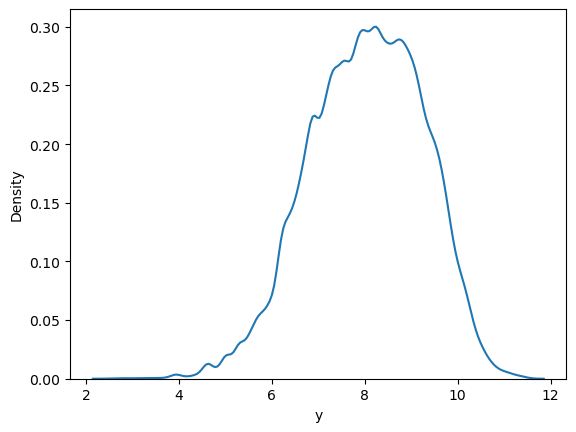

In [36]:
print(y)
print(pd.Series(y).describe())
sns.kdeplot(y)
plt.xlabel("y")
plt.show()

In [37]:
xgb = XGBRegressor(
colsample_bytree=0.8,
 gamma=0.0,
 learning_rate=0.05,
 max_depth= 8,
 min_child_weight=3,
 n_estimators=400,
 reg_lambda=1.0,
 subsample= 1.0         
)

In [38]:
%time xgb.fit(X_small, y_small)

CPU times: total: 12.8 s
Wall time: 1.24 s


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


RMSE on training set : 0.108
RMSE on validation set : 0.239
R^2 on training set : 0.992
R^2 on validation set : 0.962


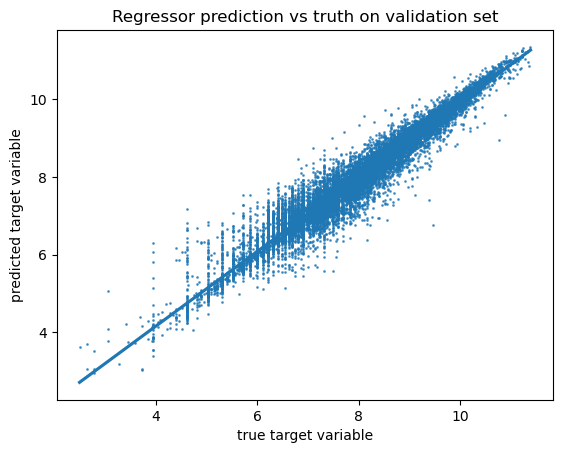

In [39]:
reg_perf(xgb, X_small, X_valid, y_small, y_valid)

CPU times: total: 20.8 s
Wall time: 1.72 s
RMSE on training set : 0.165
RMSE on validation set : 0.225
R^2 on training set : 0.982
R^2 on validation set : 0.966


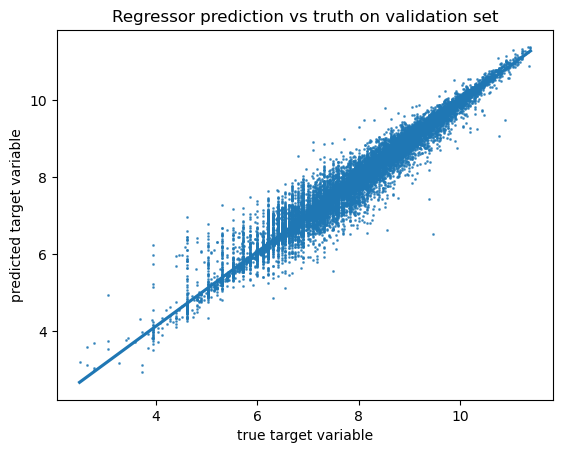

In [40]:
%time xgb.fit(X_train, y_train)
reg_perf(xgb, X_train, X_valid, y_train, y_valid)

---
## XGBoost Hyperparmeter tuning using Optuna

In [41]:
def objective(trial, X_training, y_training, X_validation, y_validation):
    
    learning_rate_guess = trial.suggest_float("learning_rate", 1e-3, 1, log=True)
    max_depth_guess = trial.suggest_int("max_depth", 2, 30, log=False)
    reg_lambda_guess = trial.suggest_int("reg_lambda", 1,100, log=False)
    colsample_bytree_guess = trial.suggest_float("colsample_bytree", 0.3, 1.0, log=False)
    min_child_weight_guess = trial.suggest_int("min_child_weight", 1, 10, log=False)
    subsample_guess = trial.suggest_float("subsample", 0.5, 1.0, log=False)
    gamma_guess = trial.suggest_float("gamma", 0.0, 5.0, log=False)
    reg_alpha_guess = trial.suggest_float("reg_alpha", 1e-8, 100.0, log=True)

    
    xgb = XGBRegressor(
        n_estimators=1000,                              
        random_state=42,
        learning_rate=learning_rate_guess,       
        max_depth=max_depth_guess, 
        reg_lambda=reg_lambda_guess,
        verbosity=0,
        colsample_bytree=colsample_bytree_guess,
        min_child_weight=min_child_weight_guess,   
        subsample=subsample_guess  ,
        gamma=gamma_guess,      
        reg_alpha=reg_alpha_guess  
    )
    
    xgb.fit(X_training, y_training)
    
    y_pred_validation = xgb.predict(X_validation)
    r2_validation = metrics.r2_score(y_validation, y_pred_validation)
    return r2_validation

In [42]:
study = optuna.create_study(study_name="xgb_opttest2", 
                            load_if_exists=True, 
                            storage = "sqlite:///opt.db",
                            direction="maximize")

study.optimize(lambda trial: objective(trial, X_small, y_small, X_valid, y_valid), n_trials=50, show_progress_bar=True)

[I 2025-12-05 00:11:54,233] A new study created in RDB with name: xgb_opttest2


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-05 00:11:54,900] Trial 0 finished with value: 0.9387952671802351 and parameters: {'learning_rate': 0.009243446597832048, 'max_depth': 2, 'reg_lambda': 12, 'colsample_bytree': 0.790911205228237, 'min_child_weight': 10, 'subsample': 0.9936880979392975, 'gamma': 4.69674811819522, 'reg_alpha': 23.857817939849063}. Best is trial 0 with value: 0.9387952671802351.
[I 2025-12-05 00:11:56,578] Trial 1 finished with value: 0.9598869315006912 and parameters: {'learning_rate': 0.01581655177472036, 'max_depth': 24, 'reg_lambda': 39, 'colsample_bytree': 0.6237945502958459, 'min_child_weight': 10, 'subsample': 0.7161828305182516, 'gamma': 0.4482065483215292, 'reg_alpha': 0.6707275233489688}. Best is trial 1 with value: 0.9598869315006912.
[I 2025-12-05 00:11:57,704] Trial 2 finished with value: 0.9465341162575203 and parameters: {'learning_rate': 0.007267230179426188, 'max_depth': 27, 'reg_lambda': 86, 'colsample_bytree': 0.6323609295116899, 'min_child_weight': 2, 'subsample': 0.8869921660

In [43]:
study.best_params

{'learning_rate': 0.02408710270051983,
 'max_depth': 17,
 'reg_lambda': 53,
 'colsample_bytree': 0.33264508047168245,
 'min_child_weight': 10,
 'subsample': 0.8007766698581315,
 'gamma': 0.003812573667986735,
 'reg_alpha': 0.010918514474559937}

[0]	validation_0-rmse:1.19382
[1]	validation_0-rmse:1.16874
[2]	validation_0-rmse:1.14417
[3]	validation_0-rmse:1.12004
[4]	validation_0-rmse:1.09605
[5]	validation_0-rmse:1.07532
[6]	validation_0-rmse:1.05335
[7]	validation_0-rmse:1.03112
[8]	validation_0-rmse:1.01002
[9]	validation_0-rmse:0.98887
[10]	validation_0-rmse:0.96840
[11]	validation_0-rmse:0.94982
[12]	validation_0-rmse:0.93056
[13]	validation_0-rmse:0.91254
[14]	validation_0-rmse:0.89418
[15]	validation_0-rmse:0.87596
[16]	validation_0-rmse:0.85862
[17]	validation_0-rmse:0.84135
[18]	validation_0-rmse:0.82465
[19]	validation_0-rmse:0.80904
[20]	validation_0-rmse:0.79329
[21]	validation_0-rmse:0.77784
[22]	validation_0-rmse:0.76282
[23]	validation_0-rmse:0.75116
[24]	validation_0-rmse:0.73757
[25]	validation_0-rmse:0.72398
[26]	validation_0-rmse:0.71035
[27]	validation_0-rmse:0.69700
[28]	validation_0-rmse:0.68404
[29]	validation_0-rmse:0.67148
[30]	validation_0-rmse:0.66043
[31]	validation_0-rmse:0.64839
[32]	validation_0-

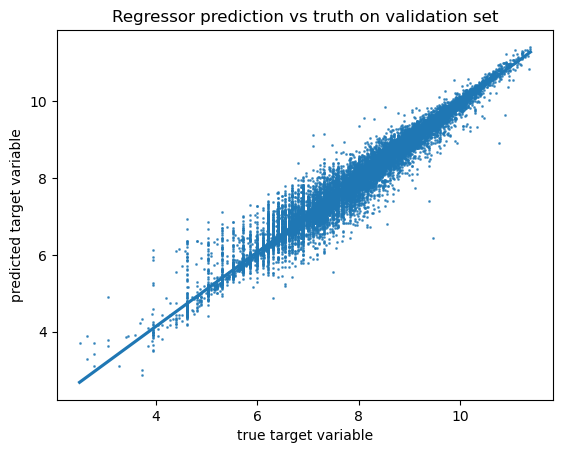

In [44]:
xgb_best = XGBRegressor(
        n_estimators=1000,                              
        random_state=42,
        learning_rate=0.02408710270051983,       
        max_depth=17, 
        reg_lambda=53,
        verbosity=0,
        colsample_bytree= 0.33264508047168245,
        min_child_weight=10,   
        subsample=0.8007766698581315  ,
        gamma=0.003812573667986735 ,
        reg_alpha   =0.010918514474559937    
)
%time xgb_best.fit(X_train, y_train, eval_set=[(X_valid, y_valid)])
reg_perf(xgb_best, X_train, X_valid, y_train, y_valid, plot=True)

In [45]:
joblib.dump(xgb_best, '../user_data/XGBoost_Model.joblib')

['../user_data/XGBoost_Model.joblib']

---
## Top 10 Important Features

---

Top 10 important features:


v_3                  0.242096
v_12                 0.178721
v_0                  0.109966
v_8                  0.094400
notRepairedDamage    0.071010
v_10                 0.063710
used_time            0.035193
bodyType_na          0.024508
v_11                 0.019593
power                0.018532
dtype: float32

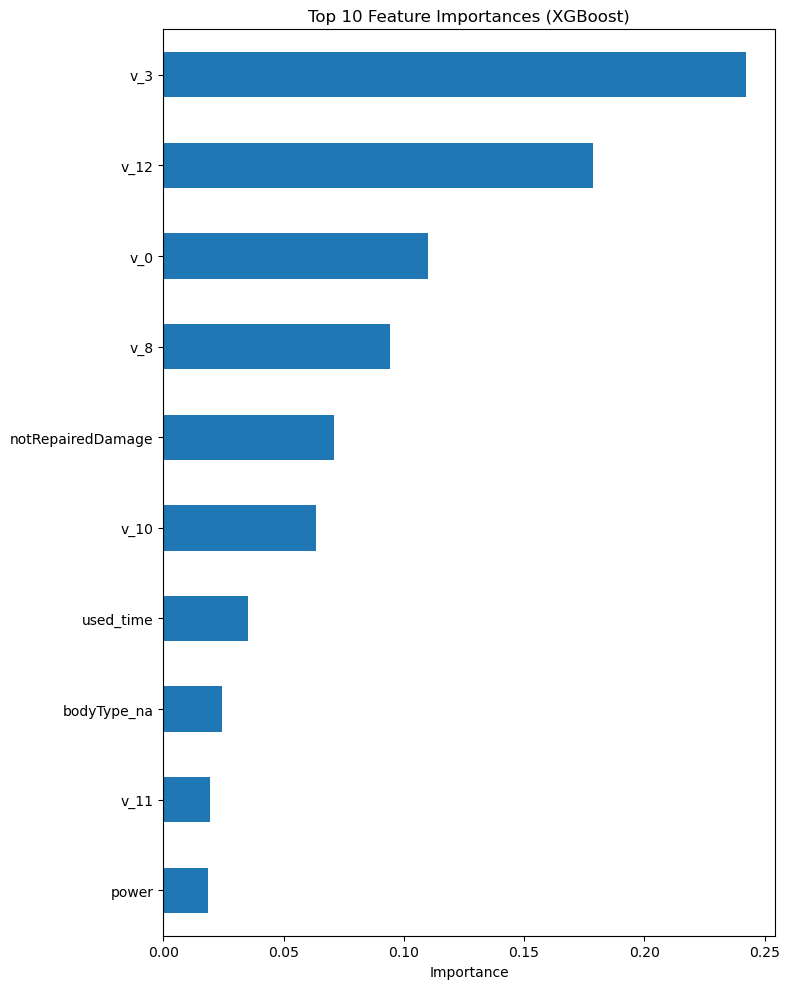

In [46]:
imp = pd.Series(xgb_best.feature_importances_, index=X_train.columns)
imp_sorted = imp.sort_values(ascending=False)
print("Top 10 important features:")
display(imp_sorted.head(10))
plt.figure(figsize=(8, 10))                  
imp_sorted.head(10).iloc[::-1].plot(kind='barh')  
plt.title(f"Top 10 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Top 10 important features:


v_3          0.446389
v_0          0.214609
v_12         0.170152
v_8          0.046276
v_10         0.036015
used_time    0.017148
v_11         0.009966
v_6          0.007293
v_1          0.005287
v_2          0.005043
dtype: float64

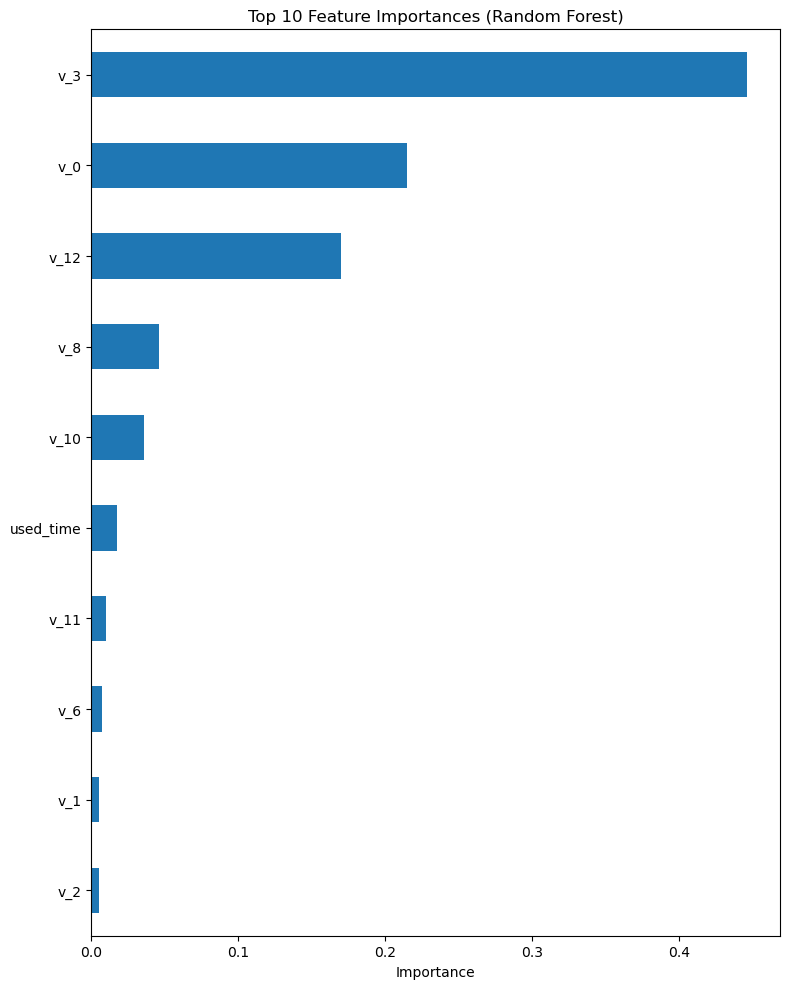

In [47]:
imp = pd.Series(rf_hybest.feature_importances_, index=X_train.columns)
imp_sorted = imp.sort_values(ascending=False)
print("Top 10 important features:")
display(imp_sorted.head(10))
plt.figure(figsize=(8, 10))                  
imp_sorted.head(10).iloc[::-1].plot(kind='barh')  
plt.title(f"Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Top 10 important features:


v_3          0.330123
v_0          0.187539
v_12         0.184510
v_8          0.100501
v_10         0.053065
used_time    0.048046
v_6          0.019158
v_11         0.013683
v_2          0.009120
power        0.007605
dtype: float64

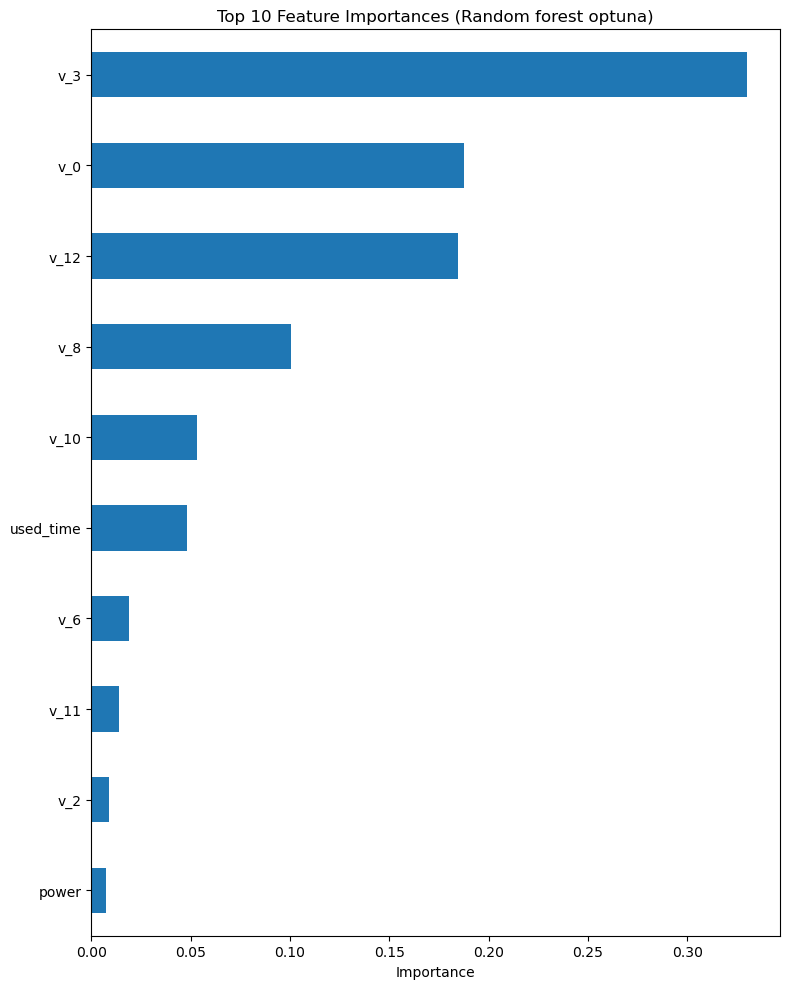

In [48]:
imp = pd.Series(rf_best.feature_importances_, index=X_train.columns)
imp_sorted = imp.sort_values(ascending=False)
print("Top 10 important features:")
display(imp_sorted.head(10))
plt.figure(figsize=(8, 10))                  
imp_sorted.head(10).iloc[::-1].plot(kind='barh')  
plt.title(f"Top 10 Feature Importances (Random forest optuna)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()